# Understanding GKP States

This notebook explores finite-energy Gottesman-Kitaev-Preskill (GKP) logical states alongside related bosonic states (squeezed, cat) used as building blocks in bosonic quantum error correction.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import cat_states, gkp_states

set_plot_style()

## System parameters

The lattice spacings $\alpha = \sqrt{\pi/2}$ and $\beta = i\sqrt{\pi/2}$ define a square-lattice GKP code. The envelope width $\Delta$ controls the finite-energy cutoff; smaller $\Delta$ gives higher effective squeezing at the cost of larger mean photon number.

In [2]:
n_fock = 80
gkp_delta = 0.3
gkp_cutoff = 10
gkp_alpha = np.sqrt(np.pi / 2)
gkp_beta = np.sqrt(np.pi / 2) * 1j

vac = qt.basis(n_fock, 0)

gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
even_cat, _ = cat_states(n_fock, gkp_alpha)
squeezed_state = qt.squeeze(n_fock, -np.log(gkp_delta)) * vac

input_squeezing_db = -10 * np.log10(gkp_delta**2)
print(f"Effective GKP squeezing: {input_squeezing_db:.2f} dB")

Effective GKP squeezing: 10.46 dB


## Wigner distributions of bosonic resource states

Compare a squeezed vacuum, an even Schrödinger-cat state, and the $\ket{0_L}$ GKP logical state.

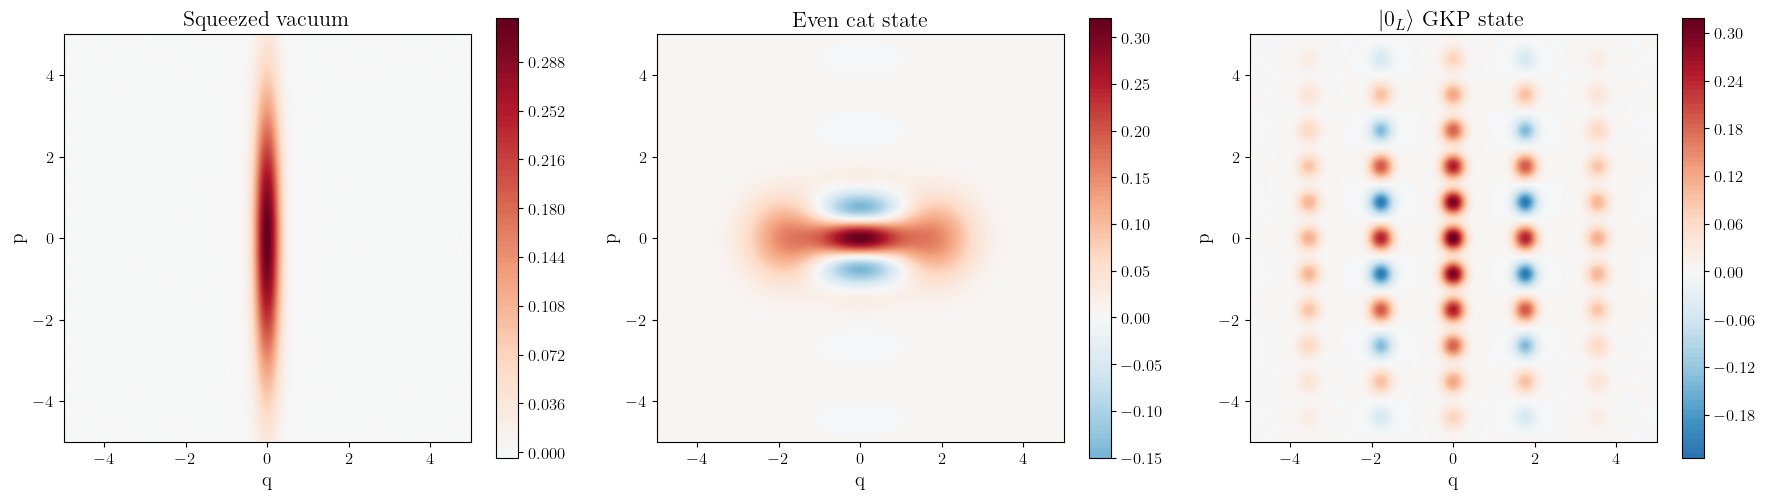

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_wigner(squeezed_state, x_bound=5, y_bound=5, ax=axes[0], title="Squeezed vacuum")
plot_wigner(even_cat, x_bound=5, y_bound=5, ax=axes[1], title="Even cat state")
plot_wigner(
    gkp_0, x_bound=5, y_bound=5, ax=axes[2], title=r"$\ket{0_L}$ GKP state"
)

fig.tight_layout()
fig.savefig("../../figs/foundations/bosonic_state_wigner_distributions.pdf", bbox_inches="tight")
plt.show()

## GKP logical cardinal states

The six cardinal states on the logical Bloch sphere: computational basis $\ket{0_L}, \ket{1_L}$, $X$-basis $\ket{\pm_L}$, and $Y$-basis $\ket{\pm i_L}$.

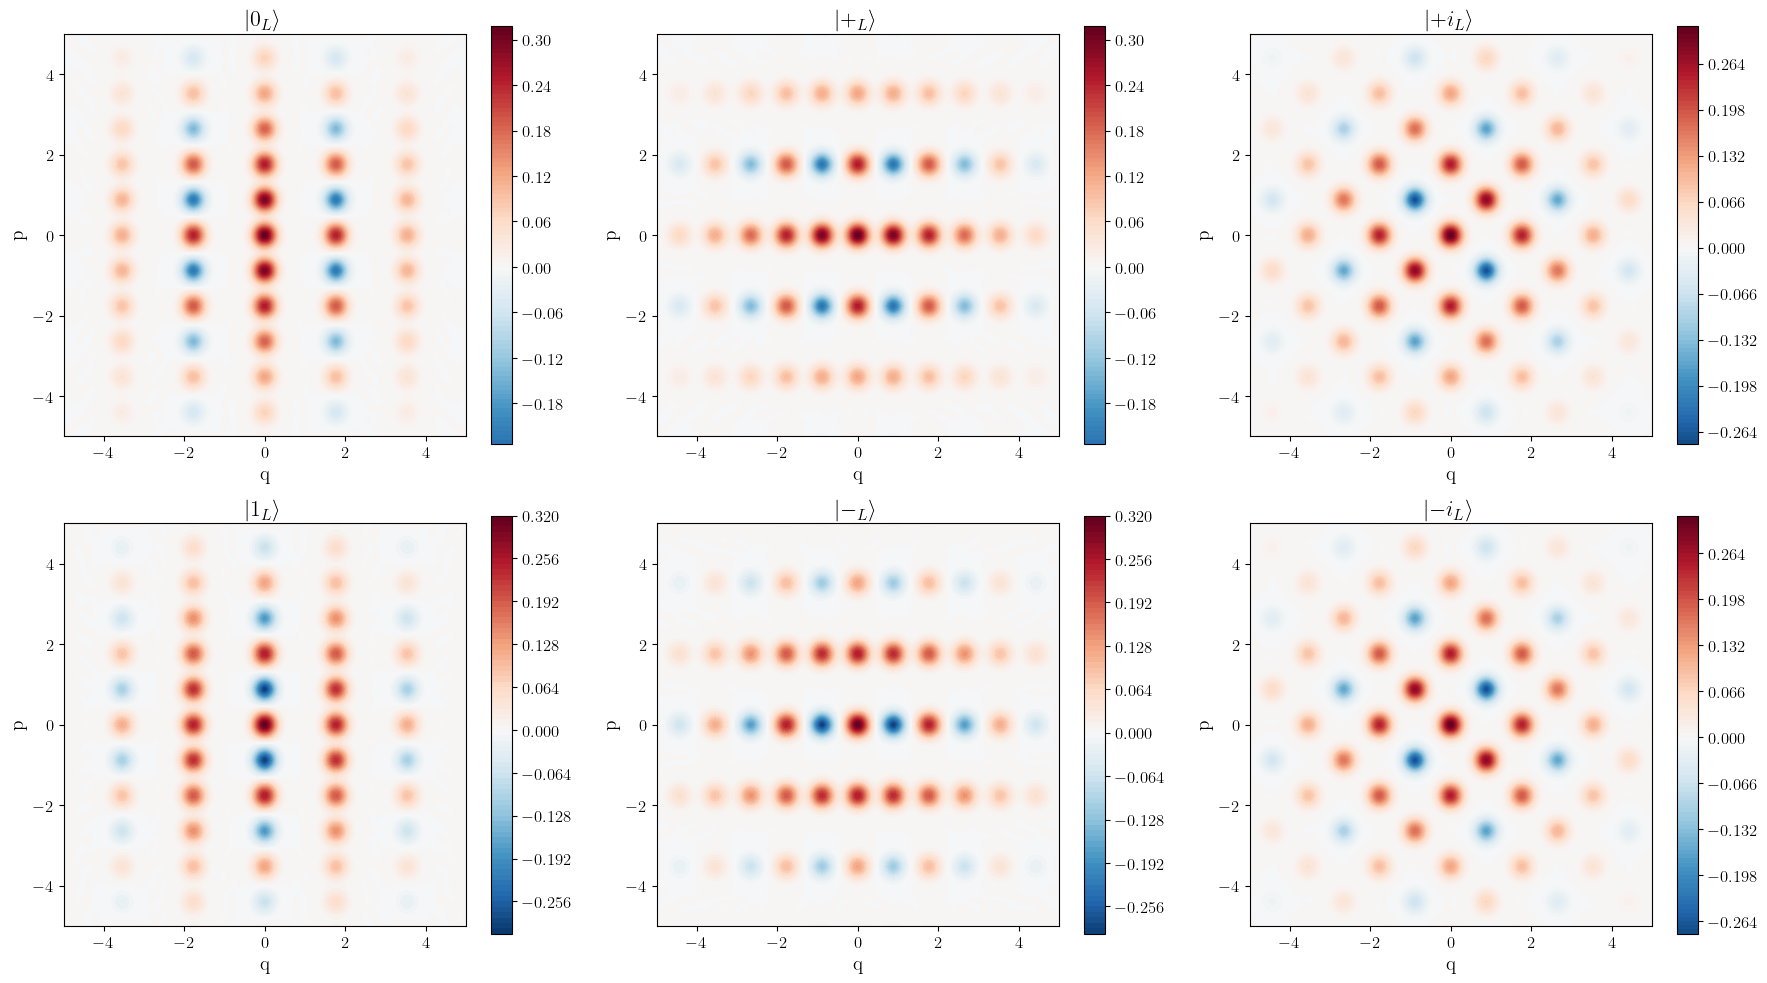

In [4]:
gkp_x_plus = (gkp_0 + gkp_1).unit()
gkp_x_minus = (gkp_0 - gkp_1).unit()
gkp_y_plus = (gkp_0 + 1j * gkp_1).unit()
gkp_y_minus = (gkp_0 - 1j * gkp_1).unit()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_wigner(gkp_0, x_bound=5, y_bound=5, ax=axes[0, 0], title=r"$\ket{0_L}$")
plot_wigner(gkp_1, x_bound=5, y_bound=5, ax=axes[1, 0], title=r"$\ket{1_L}$")
plot_wigner(gkp_x_plus, x_bound=5, y_bound=5, ax=axes[0, 1], title=r"$\ket{+_L}$")
plot_wigner(gkp_x_minus, x_bound=5, y_bound=5, ax=axes[1, 1], title=r"$\ket{-_L}$")
plot_wigner(gkp_y_plus, x_bound=5, y_bound=5, ax=axes[0, 2], title=r"$\ket{+i_L}$")
plot_wigner(gkp_y_minus, x_bound=5, y_bound=5, ax=axes[1, 2], title=r"$\ket{-i_L}$")

fig.tight_layout()
fig.savefig("../../figs/foundations/gkp_wigner_distributions.pdf", bbox_inches="tight")
plt.show()

## Photon-number distributions

Diagonal of the density matrix in the Fock basis. Useful for checking that $n_{\text{fock}}$ truncation is large enough: the probability mass near the cutoff should be negligible.

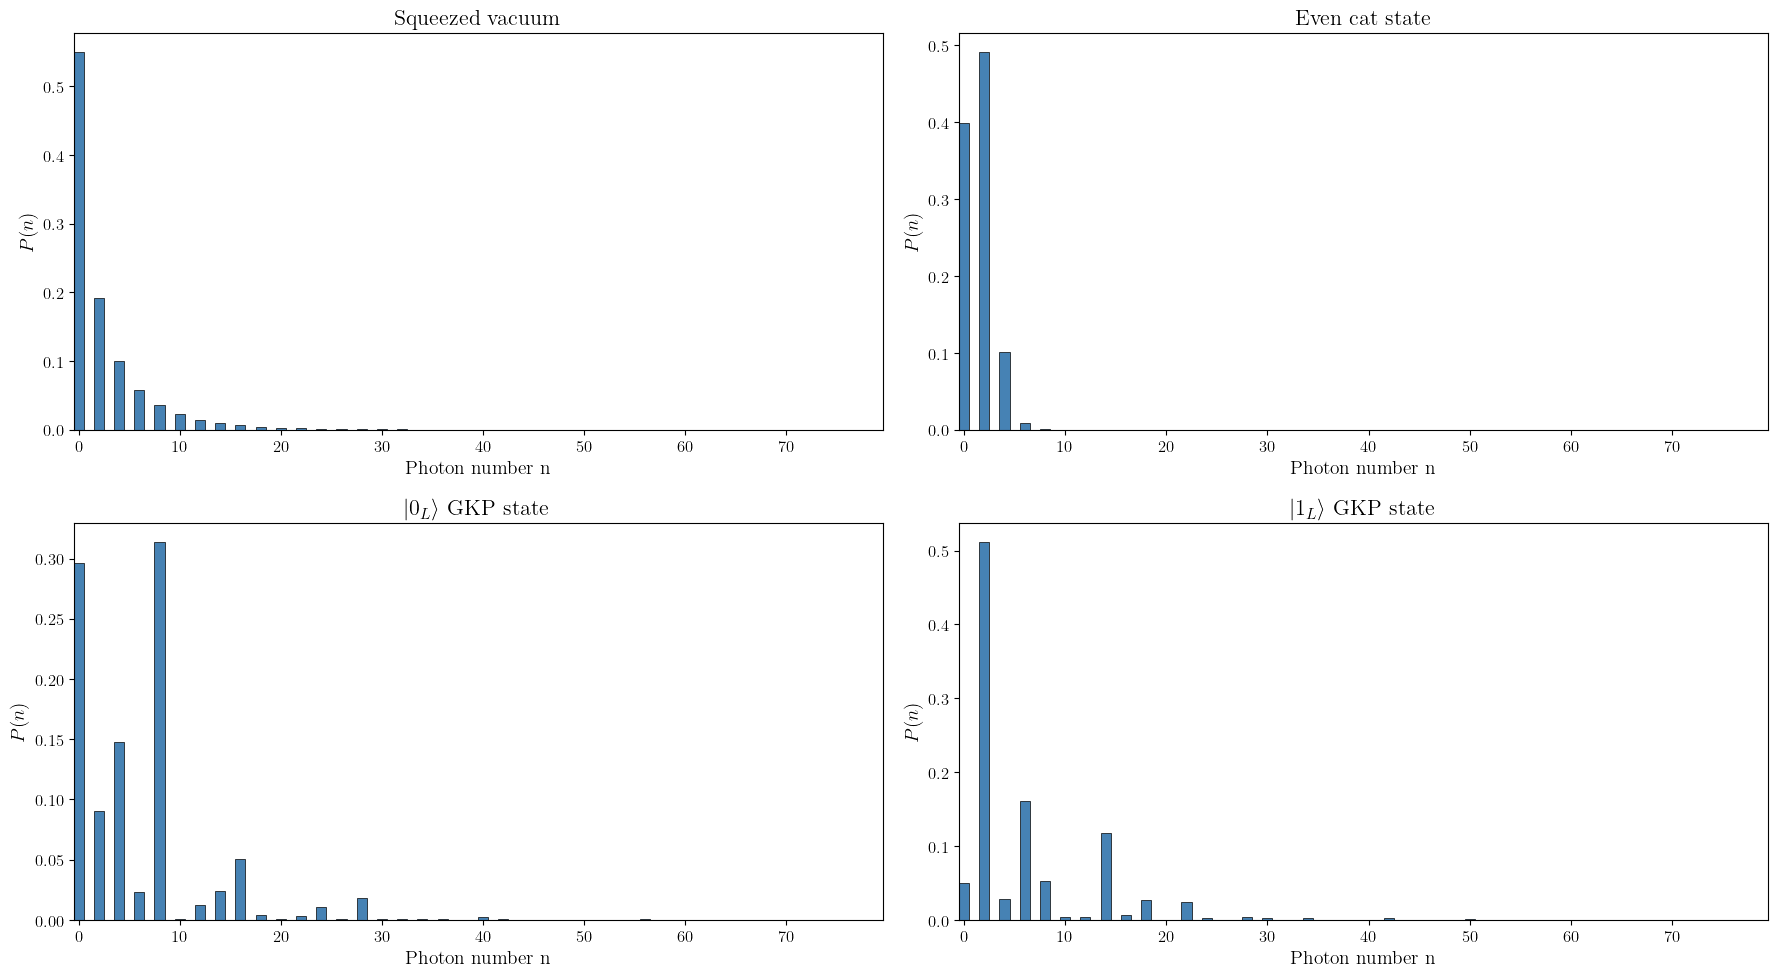

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

plot_photon_number(squeezed_state, ax=axes[0, 0], title="Squeezed vacuum")
plot_photon_number(even_cat, ax=axes[0, 1], title="Even cat state")
plot_photon_number(gkp_0, ax=axes[1, 0], title=r"$\ket{0_L}$ GKP state")
plot_photon_number(gkp_1, ax=axes[1, 1], title=r"$\ket{1_L}$ GKP state")

fig.tight_layout()
fig.savefig("../../figs/foundations/bosonic_states_photon_distributions.pdf", bbox_inches="tight")
plt.show()

## Varying GKP squeezing

Sweep the envelope parameter $\Delta$ to visualize how finite-energy GKP states approach the ideal (delta-comb) limit as $\Delta \to 0$. Smaller $\Delta$ requires a larger Fock-space truncation to faithfully represent.

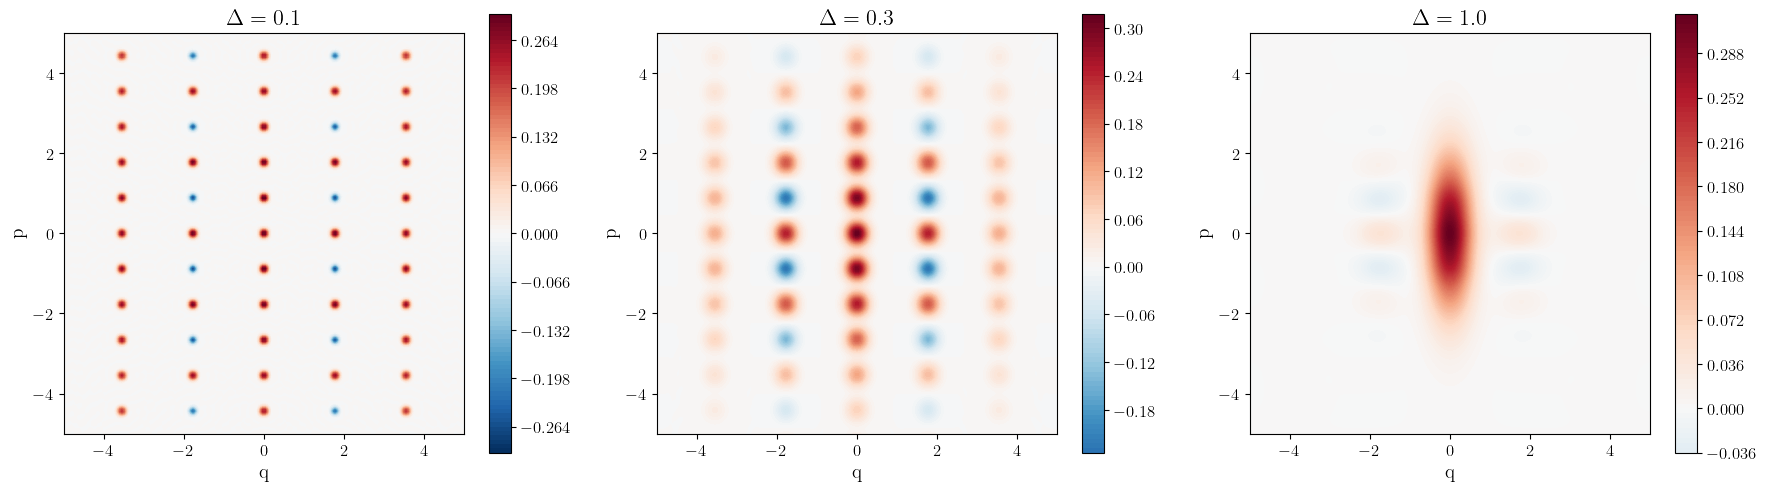

In [6]:
deltas = [0.1, 0.3, 1.0]
sweep_cutoff = 10
n_fock_min = 80

fig, axes = plt.subplots(1, len(deltas), figsize=(18, 5))

for ax, delta in zip(axes, deltas):
    n_fock_sweep = max(int(-np.log(delta) * 100), n_fock_min)
    gkp_0_sweep, _ = gkp_states(
        n_fock_sweep, gkp_alpha, gkp_beta, delta, sweep_cutoff
    )
    plot_wigner(
        gkp_0_sweep,
        x_bound=5,
        y_bound=5,
        ax=ax,
        title=rf"$\Delta = {delta}$",
    )

fig.tight_layout()
fig.savefig("../../figs/foundations/gkp_diff_squeezing_wigners.pdf", bbox_inches="tight")
plt.show()